# Combined Screening Example — Residue Contacts + Surface Overlap

End-to-end demonstration of scoring docked poses using:

1. **Residue contact scoring** — Tversky, Jaccard, coverage metrics
2. **Surface overlap scoring** — fraction of pocket vertices covered by ligand atoms
3. **Combined scoring** — weighted combination selecting the best pose across all pockets

**Inputs (DRD5 example):**
- `pocket_residue_contacts_ang_3.csv` — residue contacts per pocket
- `pockets.npz` — pocket surface vertices
- `annotated_interactions.csv` — annotated ligand–residue interactions
- `glide_real_sdf_1.sdf` — docked ligand poses (standardised SDF)

In [10]:
from pathlib import Path

import numpy as np
import pandas as pd
from rdkit import Chem

from pocket_ligand_screener.screener import (
    ResidueContactScorer,
    SurfaceOverlapScorer,
    annotate_all_pockets,
    coords_from_mol,
    score_all_poses,
    select_best_pose,
)

## 1. Load data

Load pocket definitions (residue contacts + surface vertices), annotated interactions, and docked poses.

In [12]:
DATA_DIR = Path("../tests/test_data/drd5_example")

# Pocket residue contacts
pocket_csv_path = DATA_DIR / "pocket_residue_contacts_ang_3.csv"
pocket_df = pd.read_csv(pocket_csv_path)
print(f"Pocket CSV: {pocket_df.shape[0]} rows")
print(f"Pockets: {pocket_df['pocket'].unique().tolist()}")

# Annotated interactions
interactions_csv = DATA_DIR / "annotated_interactions.csv"
interactions_df = pd.read_csv(interactions_csv)
print(f"\nInteractions: {interactions_df.shape[0]} rows")
print(f"Poses: {sorted(interactions_df['docked_ligand_index'].unique())}")

# Docked poses SDF
sdf_path = Path("../tests/test_data/glide_real_sdf_1.sdf")
supplier = Chem.SDMolSupplier(str(sdf_path), removeHs=False)
mols = [m for m in supplier if m is not None]
print(f"\nSDF: {len(mols)} mol objects loaded")

# Pocket surface vertices
npz_path = DATA_DIR / "pockets.npz"

Pocket CSV: 67 rows
Pockets: ['C1=_pocket_1', 'C1=_pocket_2', 'C1=_pocket_3']

Interactions: 1531 rows
Poses: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

SDF: 24 mol objects loaded


## 2. Residue contact scoring

Create a `ResidueContactScorer` per pocket and compare the four scoring metrics:
**count**, **coverage**, **Jaccard**, **Tversky**.

In [13]:
pocket_names = pocket_df["pocket"].unique().tolist()

# Build a scorer per pocket
residue_scorers = {
    name: ResidueContactScorer(pocket_csv_path, pocket_name=name)
    for name in pocket_names
}

# Show pocket residue counts
for name, scorer in residue_scorers.items():
    print(f"{name}: {len(scorer.pocket_residues)} residues")

C1=_pocket_1: 15 residues
C1=_pocket_2: 9 residues
C1=_pocket_3: 6 residues


In [15]:
# Score all poses against all pockets using residue metrics only
residue_rows = []
for pose_idx, pose_df in interactions_df.groupby("docked_ligand_index"):
    for pocket_name, scorer in residue_scorers.items():
        scores = scorer.score_all(pose_df, alpha=1.0, beta=0.3)
        scores["docked_ligand_index"] = pose_idx
        scores["pocket_name"] = pocket_name
        residue_rows.append(scores)

residue_scores_df = pd.DataFrame(residue_rows)
residue_scores_df = residue_scores_df[
    ["docked_ligand_index", "pocket_name", "count", "coverage", "jaccard", "tversky"]
]

print(f"Score matrix: {residue_scores_df.shape[0]} rows "
      f"({interactions_df['docked_ligand_index'].nunique()} poses × {len(pocket_names)} pockets)")
residue_scores_df.sort_values(["pocket_name", "tversky"], ascending=[True, False]).head(12)

Score matrix: 72 rows (24 poses × 3 pockets)


,docked_ligand_index,pocket_name,count,coverage,jaccard,tversky
51,17,C1=_pocket_1,14.0,0.933333,0.823529,0.897436
36,12,C1=_pocket_1,13.0,0.866667,0.722222,0.817610
0,0,C1=_pocket_1,12.0,0.800000,0.666667,0.754717
15,5,C1=_pocket_1,12.0,0.800000,0.666667,0.754717
63,21,C1=_pocket_1,12.0,0.800000,0.666667,0.754717
45,15,C1=_pocket_1,11.0,0.733333,0.647059,0.705128
48,16,C1=_pocket_1,11.0,0.733333,0.611111,0.691824
18,6,C1=_pocket_1,11.0,0.733333,0.578947,0.679012
12,4,C1=_pocket_1,10.0,0.666667,0.526316,0.617284
21,7,C1=_pocket_1,9.0,0.600000,0.500000,0.566038


### Heatmap — Tversky scores per pose × pocket

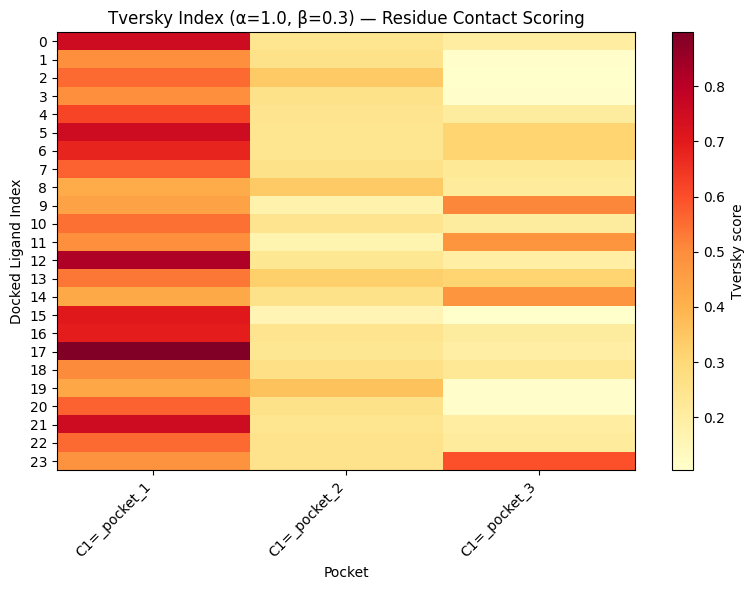

In [16]:
import matplotlib.pyplot as plt

pivot = residue_scores_df.pivot(
    index="docked_ligand_index", columns="pocket_name", values="tversky"
)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("Pocket")
ax.set_ylabel("Docked Ligand Index")
ax.set_title("Tversky Index (α=1.0, β=0.3) — Residue Contact Scoring")
fig.colorbar(im, ax=ax, label="Tversky score")
plt.tight_layout()
plt.show()

## 3. Surface overlap scoring

Create a `SurfaceOverlapScorer` from `pockets.npz` and score each pose by the fraction of pocket vertices covered by ligand atoms (within 2.5 Å cutoff).

In [18]:
surface_scorer = SurfaceOverlapScorer(npz_path, distance_cutoff=2.5)

for name, vertices in surface_scorer.pockets.items():
    print(f"{name}: {vertices.shape[0]} vertices")

C1=_pocket_1: 188 vertices
C1=_pocket_2: 152 vertices
C1=_pocket_3: 54 vertices


In [19]:
# Score each pose against each pocket
surface_rows = []
for i, mol in enumerate(mols):
    coords = coords_from_mol(mol)
    pocket_scores = surface_scorer.score_all_pockets(coords)
    for pocket_name, cov in pocket_scores.items():
        surface_rows.append({
            "docked_ligand_index": i,
            "pocket_name": pocket_name,
            "surface_coverage": cov,
            "vertices_covered": surface_scorer.score_count(coords, pocket_name=pocket_name),
        })

surface_scores_df = pd.DataFrame(surface_rows)
print(f"Score matrix: {surface_scores_df.shape[0]} rows")
surface_scores_df.sort_values(["pocket_name", "surface_coverage"], ascending=[True, False]).head(12)

Score matrix: 72 rows


,docked_ligand_index,pocket_name,surface_coverage,vertices_covered
0,0,C1=_pocket_1,1.0,188
6,2,C1=_pocket_1,1.0,188
12,4,C1=_pocket_1,1.0,188
15,5,C1=_pocket_1,1.0,188
21,7,C1=_pocket_1,1.0,188
27,9,C1=_pocket_1,1.0,188
30,10,C1=_pocket_1,1.0,188
36,12,C1=_pocket_1,1.0,188
45,15,C1=_pocket_1,1.0,188
48,16,C1=_pocket_1,1.0,188


### Heatmap — Surface coverage per pose × pocket

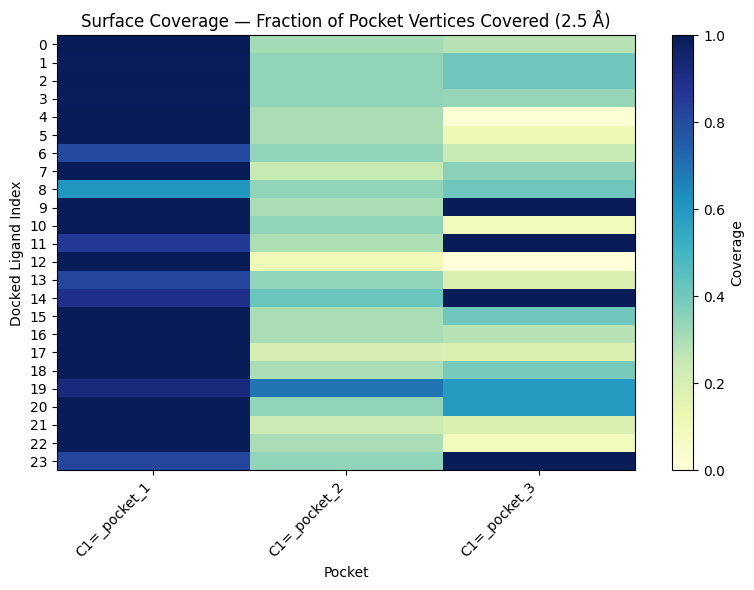

In [20]:
pivot_surf = surface_scores_df.pivot(
    index="docked_ligand_index", columns="pocket_name", values="surface_coverage"
)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot_surf.values, aspect="auto", cmap="YlGnBu")
ax.set_xticks(range(len(pivot_surf.columns)))
ax.set_xticklabels(pivot_surf.columns, rotation=45, ha="right")
ax.set_yticks(range(len(pivot_surf.index)))
ax.set_yticklabels(pivot_surf.index)
ax.set_xlabel("Pocket")
ax.set_ylabel("Docked Ligand Index")
ax.set_title("Surface Coverage — Fraction of Pocket Vertices Covered (2.5 Å)")
fig.colorbar(im, ax=ax, label="Coverage")
plt.tight_layout()
plt.show()

## 4. Combined scoring

Use `score_all_poses` to compute both residue and surface metrics together, then `select_best_pose` to pick the winning pose (aggregated across all pockets).

In [21]:
# Re-load supplier (iterators are consumed)
supplier = Chem.SDMolSupplier(str(sdf_path), removeHs=False)

combined_scores_df = score_all_poses(
    interactions_df=interactions_df,
    residue_scorers=residue_scorers,
    surface_scorer=surface_scorer,
    sdf_supplier=supplier,
    alpha=1.0,
    beta=0.3,
    residue_weight=0.6,
    surface_weight=0.4,
)

print(f"Combined scores: {combined_scores_df.shape}")
combined_scores_df.sort_values("combined_score", ascending=False).head(12)

Combined scores: (72, 8)


,docked_ligand_index,pocket_name,residue_count,residue_coverage,residue_jaccard,residue_tversky,surface_coverage,combined_score
51,17,C1=_pocket_1,14.0,0.933333,0.823529,0.897436,1.0,0.938462
36,12,C1=_pocket_1,13.0,0.866667,0.722222,0.817610,1.0,0.890566
15,5,C1=_pocket_1,12.0,0.800000,0.666667,0.754717,1.0,0.852830
63,21,C1=_pocket_1,12.0,0.800000,0.666667,0.754717,1.0,0.852830
0,0,C1=_pocket_1,12.0,0.800000,0.666667,0.754717,1.0,0.852830
45,15,C1=_pocket_1,11.0,0.733333,0.647059,0.705128,1.0,0.823077
48,16,C1=_pocket_1,11.0,0.733333,0.611111,0.691824,1.0,0.815094
12,4,C1=_pocket_1,10.0,0.666667,0.526316,0.617284,1.0,0.770370
71,23,C1=_pocket_3,5.0,0.833333,0.357143,0.595238,1.0,0.757143
21,7,C1=_pocket_1,9.0,0.600000,0.500000,0.566038,1.0,0.739623


In [23]:
# Select the best pose across all pockets
best = select_best_pose(combined_scores_df, rank_by="combined_score", aggregation="sum")

print(f"Best pose: docked_ligand_index = {best['docked_ligand_index'].iloc[0]}")
print(f"Aggregated score: {best['aggregated_score'].iloc[0]:.4f}\n")
best

Best pose: docked_ligand_index = 23
Aggregated score: 1.6626



,docked_ligand_index,pocket_name,residue_count,residue_coverage,residue_jaccard,residue_tversky,surface_coverage,combined_score,aggregated_score
0,23,C1=_pocket_1,8.0,0.533333,0.400000,0.484848,0.819149,0.618569,1.662554
1,23,C1=_pocket_2,3.0,0.333333,0.157895,0.250000,0.342105,0.286842,1.662554
2,23,C1=_pocket_3,5.0,0.833333,0.357143,0.595238,1.000000,0.757143,1.662554


### Side-by-side comparison of all score components

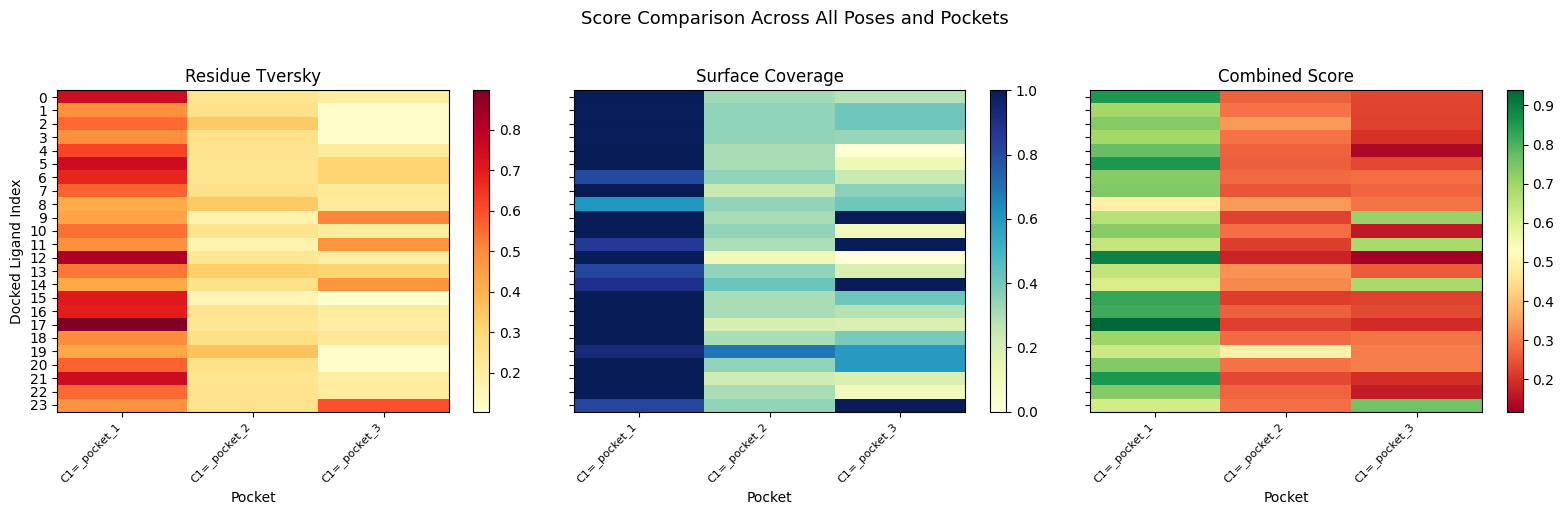

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

cols = ["residue_tversky", "surface_coverage", "combined_score"]
titles = ["Residue Tversky", "Surface Coverage", "Combined Score"]
cmaps = ["YlOrRd", "YlGnBu", "RdYlGn"]

for ax, col, title, cmap in zip(axes, cols, titles, cmaps):
    pivot = combined_scores_df.pivot(
        index="docked_ligand_index", columns="pocket_name", values=col
    )
    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(title)
    ax.set_xlabel("Pocket")
    fig.colorbar(im, ax=ax)

axes[0].set_ylabel("Docked Ligand Index")
plt.suptitle("Score Comparison Across All Poses and Pockets", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Pocket annotation

Add a `pocket_name` column to every interaction row — shows which pocket each residue contact belongs to (or `None` if outside all pockets).

In [25]:
annotated = annotate_all_pockets(interactions_df, residue_scorers)

print(f"Original rows: {len(interactions_df)}")
print(f"Annotated rows: {len(annotated)} (expanded for multi-pocket residues)")
print(f"Pocket assignments: {annotated['pocket_name'].value_counts(dropna=False).to_dict()}")
annotated.head(10)

Original rows: 1531
Annotated rows: 1717 (expanded for multi-pocket residues)
Pocket assignments: {'C1=_pocket_1': 1083, 'C1=_pocket_2': 354, 'C1=_pocket_3': 255, None: 25}


,docked_ligand_index,interaction_type,ligand_atom_indices,ligand_atom_types,residue_name,residue_number,residue_atom_indices,residue_atom_types,residue_atom_bb_sc,interaction_distance,functional_groups,pocket_name
0,0,Hydrophobic,"(13,)","('C',)",PHE,313,"(3713,)","('C',)","('sc',)",3.990,"('No_fg',)",C1=_pocket_1
1,0,Hydrophobic,"(15,)","('C',)",PHE,313,"(3711,)","('C',)","('sc',)",4.084,"('No_fg',)",C1=_pocket_1
2,0,Hydrophobic,"(15,)","('C',)",PHE,313,"(3713,)","('C',)","('sc',)",3.768,"('No_fg',)",C1=_pocket_1
3,0,Hydrophobic,"(16,)","('C',)",PHE,313,"(3711,)","('C',)","('sc',)",3.928,"('No_fg',)",C1=_pocket_1
4,0,Hydrophobic,"(16,)","('C',)",PHE,313,"(3713,)","('C',)","('sc',)",4.100,"('No_fg',)",C1=_pocket_1
5,0,VdWContact,"(37,)","('H',)",SER,124,"(1363,)","('C',)","('sc',)",2.682,"('No_fg',)",C1=_pocket_1
6,0,VdWContact,"(37,)","('H',)",SER,124,"(1367,)","('H',)","('sc',)",2.126,"('No_fg',)",C1=_pocket_1
7,0,Hydrophobic,"(19,)","('C',)",PHE,341,"(3963,)","('C',)","('sc',)",3.845,"('No_fg',)",C1=_pocket_3
8,0,Hydrophobic,"(20,)","('C',)",PHE,341,"(3961,)","('C',)","('sc',)",3.835,"('No_fg',)",C1=_pocket_3
9,0,Hydrophobic,"(20,)","('C',)",PHE,341,"(3963,)","('C',)","('sc',)",3.480,"('No_fg',)",C1=_pocket_3


### Filter: interactions for the best pose that fall inside a pocket

In [26]:
best_idx = best["docked_ligand_index"].iloc[0]
best_annotated = annotated[
    (annotated["docked_ligand_index"] == best_idx)
    & (annotated["pocket_name"].notna())
]

print(f"Best pose {best_idx}: {len(best_annotated)} in-pocket interactions\n")
print("Pocket breakdown:")
print(best_annotated.groupby("pocket_name")["interaction_type"].value_counts().to_string())

Best pose 23: 93 in-pocket interactions

Pocket breakdown:
pocket_name   interaction_type
C1=_pocket_1  Hydrophobic         27
              VdWContact          18
              PiStacking           1
C1=_pocket_2  VdWContact          16
              Hydrophobic          2
C1=_pocket_3  Hydrophobic         15
              VdWContact          14


## 6. Aggregation comparison

Compare different aggregation strategies (`sum`, `mean`, `max`) to see if they select the same best pose.

In [28]:
for agg in ["sum", "mean", "max"]:
    b = select_best_pose(combined_scores_df, rank_by="combined_score", aggregation=agg)
    idx = b["docked_ligand_index"].iloc[0]
    agg_score = b["aggregated_score"].iloc[0]
    print(f"  aggregation={agg:4s} → best pose = {idx}, aggregated_score = {agg_score:.4f}")

  aggregation=sum  → best pose = 23, aggregated_score = 1.6626
  aggregation=mean → best pose = 23, aggregated_score = 0.5542
  aggregation=max  → best pose = 17, aggregated_score = 0.9385
